In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

## Extract Data from log.lammps File

In [2]:
# Read the log file and extract thermodynamic data
step = []
volume = []
pressure = []
temperature = []
pot_energy = []
kin_energy = []
tot_energy = []

with open('log.lammps', 'r') as f:
    lines = f.readlines()
    
    # Find the start of thermodynamic data
    reading_data = False
    for line in lines:
        # Check if we're at the header line
        if 'Step' in line and 'Volume' in line and 'Press' in line:
            reading_data = True
            continue
        
        # Stop reading at "Loop time" which marks the end of the run
        if 'Loop time' in line:
            reading_data = False
            continue
        
        # Read data lines
        if reading_data:
            # Try to parse the line as data
            parts = line.split()
            if len(parts) == 7:  # Step, Vol, Press, Temp, PotEng, KinEng, TotEng
                try:
                    step.append(int(parts[0]))
                    volume.append(float(parts[1]))
                    pressure.append(float(parts[2]))
                    temperature.append(float(parts[3]))
                    pot_energy.append(float(parts[4]))
                    kin_energy.append(float(parts[5]))
                    tot_energy.append(float(parts[6]))
                except ValueError:
                    pass  # Skip lines that can't be parsed

# Convert to numpy arrays
step = np.array(step)
volume = np.array(volume)
pressure = np.array(pressure)
temperature = np.array(temperature)
tot_energy = np.array(tot_energy)

# Calculate time (timestep is 0.001 ps from the input file)
timestep = 0.001  # ps
time = step * timestep  # in picoseconds

print(f"Data points extracted: {len(step)}")
print(f"Time range: {time[0]} ps to {time[-1]} ps")

Data points extracted: 1004
Time range: 0.0 ps to 10.019 ps


## Create Plots

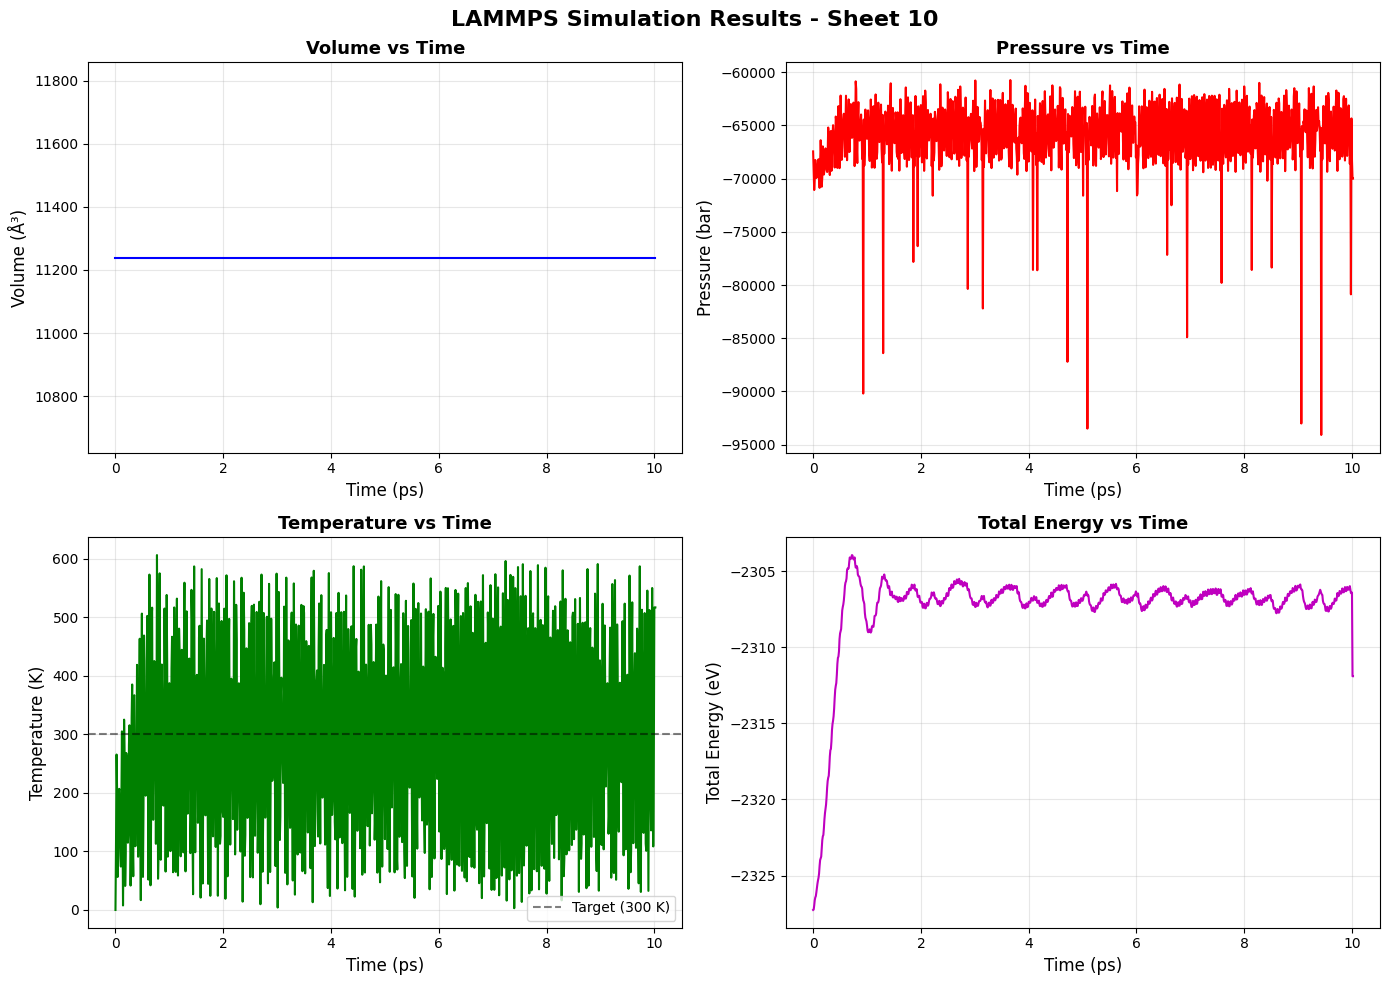


Plots saved as 'simulation_analysis.png'


In [3]:
# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LAMMPS Simulation Results - Sheet 10', fontsize=16, fontweight='bold')

# Plot 1: Volume vs Time
axes[0, 0].plot(time, volume, 'b-', linewidth=1.5)
axes[0, 0].set_xlabel('Time (ps)', fontsize=12)
axes[0, 0].set_ylabel('Volume (Å³)', fontsize=12)
axes[0, 0].set_title('Volume vs Time', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Pressure vs Time
axes[0, 1].plot(time, pressure, 'r-', linewidth=1.5)
axes[0, 1].set_xlabel('Time (ps)', fontsize=12)
axes[0, 1].set_ylabel('Pressure (bar)', fontsize=12)
axes[0, 1].set_title('Pressure vs Time', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Temperature vs Time
axes[1, 0].plot(time, temperature, 'g-', linewidth=1.5)
axes[1, 0].set_xlabel('Time (ps)', fontsize=12)
axes[1, 0].set_ylabel('Temperature (K)', fontsize=12)
axes[1, 0].set_title('Temperature vs Time', fontsize=13, fontweight='bold')
axes[1, 0].axhline(y=300, color='k', linestyle='--', alpha=0.5, label='Target (300 K)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Total Energy vs Time
axes[1, 1].plot(time, tot_energy, 'm-', linewidth=1.5)
axes[1, 1].set_xlabel('Time (ps)', fontsize=12)
axes[1, 1].set_ylabel('Total Energy (eV)', fontsize=12)
axes[1, 1].set_title('Total Energy vs Time', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simulation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlots saved as 'simulation_analysis.png'")

## Temperature is not 'fixed'? -> damping?

## Statistical Summary

In [4]:
# Print statistical summary
print("=" * 60)
print("Statistical Summary of Simulation")
print("=" * 60)

print(f"\nVolume (Å³):")
print(f"  Mean: {np.mean(volume):.2f}")
print(f"  Std Dev: {np.std(volume):.2f}")
print(f"  Min: {np.min(volume):.2f}")
print(f"  Max: {np.max(volume):.2f}")

print(f"\nPressure (bar):")
print(f"  Mean: {np.mean(pressure):.2f}")
print(f"  Std Dev: {np.std(pressure):.2f}")
print(f"  Min: {np.min(pressure):.2f}")
print(f"  Max: {np.max(pressure):.2f}")

print(f"\nTemperature (K):")
print(f"  Mean: {np.mean(temperature):.2f}")
print(f"  Std Dev: {np.std(temperature):.2f}")
print(f"  Min: {np.min(temperature):.2f}")
print(f"  Max: {np.max(temperature):.2f}")
print(f"  Target: 300.00")

print(f"\nTotal Energy (eV):")
print(f"  Mean: {np.mean(tot_energy):.4f}")
print(f"  Std Dev: {np.std(tot_energy):.4f}")
print(f"  Min: {np.min(tot_energy):.4f}")
print(f"  Max: {np.max(tot_energy):.4f}")
print(f"  Energy drift: {tot_energy[-1] - tot_energy[0]:.4f} eV")

print("\n" + "=" * 60)

Statistical Summary of Simulation

Volume (Å³):
  Mean: 11239.42
  Std Dev: 0.00
  Min: 11239.42
  Max: 11239.42

Pressure (bar):
  Mean: -65951.39
  Std Dev: 3306.86
  Min: -94095.60
  Max: -60736.66

Temperature (K):
  Mean: 295.15
  Std Dev: 162.59
  Min: 0.00
  Max: 606.61
  Target: 300.00

Total Energy (eV):
  Mean: -2307.3453
  Std Dev: 3.1061
  Min: -2327.2583
  Max: -2303.9522
  Energy drift: 15.3505 eV

